# Car Price Analysis with Multiple Regression Models

This notebook performs a comprehensive analysis of car prices using multiple regression approaches including linear, log-transformed, ensemble, and XGBoost models. The analysis focuses on ludospace vehicle models and explores different approaches to price prediction and deal identification.

In [4]:
from datetime import datetime
print(f"Last execution date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Last execution date: 2025-09-25 21:23:04


## Overview
- Load and explore the dataset of ludospace vehicles
- Apply feature engineering and preprocessing
- Compare linear vs log-transformed price models
- Evaluate model performance using MAPE, MAE, and R² metrics
- Find the most interesting car deals based on predicted vs actual prices

## 1. Setup and Imports

First, we import all necessary libraries and set up the environment:
- Database connection utilities for loading car data
- Scikit-learn modules for machine learning (PLS, preprocessing, metrics)
- Data manipulation and visualization libraries

In [5]:
import sys
import os

# Add src to path
sys.path.append(os.path.abspath('../src'))

# Data and database imports
from data.database import get_car_items, get_car_models
from data.preprocessing import clean_car_dataset, prepare_training_data, create_car_clusters, enrich_dataset_with_predictions

# Model imports
from models.price_models import (
    create_simple_linear_model, create_log_transformed_model, 
    create_xgboost_model, create_ensemble_model,
    get_linear_model_formula, get_log_model_formula
)

# Utility imports
from utils.config import LUDOSPACE_MODELS, IGNORE_URLS, ANALYSIS_CONFIG, DEFAULT_FILTERS
from utils.visualization import show_cars
from utils.plotting import plot_data_distributions, plot_clustering_results, plot_model_predictions_vs_actual, plot_relative_error_histograms

# Standard ML and data science imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

# Display configuration
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 80)

## 2. Data Loading and Exploration

Load the ludospace vehicle dataset and perform initial exploration:
- Load specific ludospace models (van-like vehicles with good space utilization)
- Clean the dataset by removing records with missing essential data
- Examine the distribution of models and price ranges

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Ignoring cars with 2, 3, 4 seats
Ignoring cars with 47, 67 horse power (berlingo 22kW)
Ignoring cars with distance > 1500 km
Ignoring 14 problematic URLs

TOP MOST FREQUENT MODELS
                          count_before_cleaning  price_count  price_min  price_max
model                                                                             
CITROEN_Berlingo                            428          220       7490      41700
RENAULT_Kangoo                              467          107       1000      42960
PEUGEOT_Rifter                               56           52      15184      37990
MERCEDES-BENZ_EQT                            42           42      20890      49559
NISSAN_Townstar                              82           14       4668      35890
OPEL_Combo                                   47           12      17999      29900
OPEL_Combo Life                              11           11      19490      27490
TOYOTA_PROACE CITY Verso                     10            9      23490  

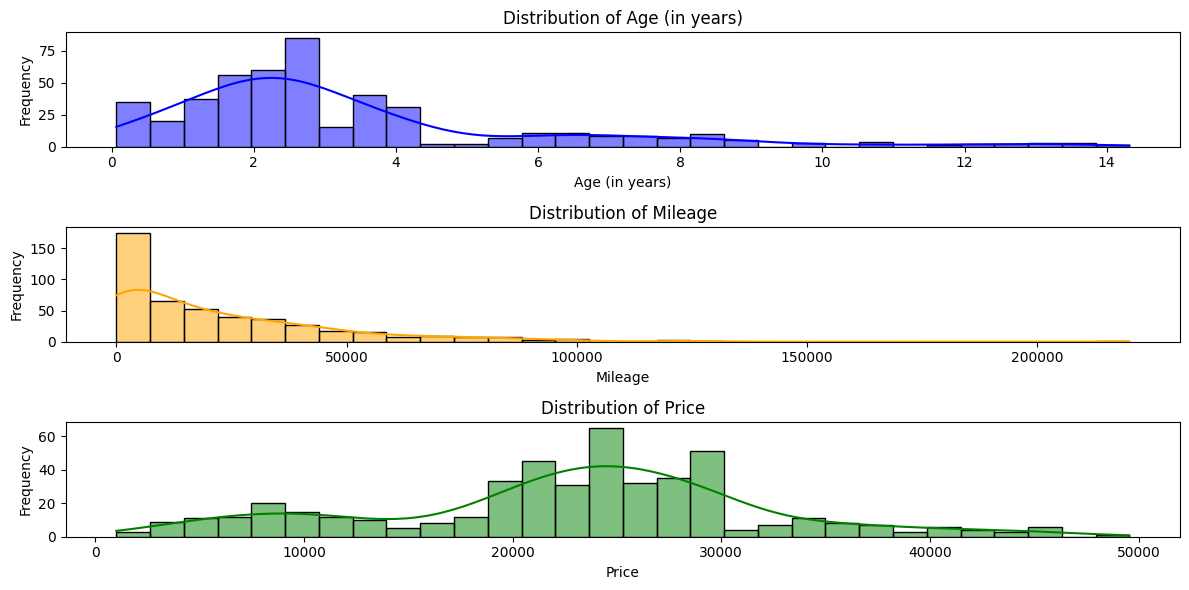

In [6]:
# Load and clean the dataset
full_raw_dataset = get_car_items(models=LUDOSPACE_MODELS, table='all_car_items')

# Clean the dataset using our preprocessing utilities
print(f"Ignoring cars with {", ".join(map(str, ANALYSIS_CONFIG['ignore_seats']))} seats")
print(f"Ignoring cars with {", ".join(map(str, ANALYSIS_CONFIG['ignore_horse_power']))} horse power (berlingo 22kW)")
print(f"Ignoring cars with distance > {ANALYSIS_CONFIG['max_distance']} km")
print(f"Ignoring {len(IGNORE_URLS)} problematic URLs") if IGNORE_URLS and len(IGNORE_URLS) > 0 else None
cleaned_raw_dataset = clean_car_dataset(
    full_raw_dataset, 
    ignore_urls=IGNORE_URLS,
    max_distance=ANALYSIS_CONFIG['max_distance'],
    ignore_horse_power=ANALYSIS_CONFIG['ignore_horse_power'],
    ignore_seats=ANALYSIS_CONFIG['ignore_seats']
)

# Display model statistics (including the count of price per model from full dataset before cleaning)
print("\nTOP MOST FREQUENT MODELS")
print("="*80)
before_cleaning_counts = full_raw_dataset.groupby('model').agg({
    'price': ['count']
})
# Flatten columns for easier merge
before_cleaning_counts.columns = ['count_before_cleaning']

model_stats = cleaned_raw_dataset.groupby('model').agg({
    'price': ['count', 'min', 'max']
})

# Flatten the multi-level columns for model_stats
model_stats.columns = ['_'.join(col).strip() for col in model_stats.columns.values]

# Merge the before_cleaning_counts into model_stats
model_stats = before_cleaning_counts.merge(model_stats, left_index=True, right_index=True, how='left').sort_values(by=('price_count'), ascending=False)

print(model_stats)

# Plot data distributions
plot_data_distributions(cleaned_raw_dataset)

In [7]:
print("TOP MOST RECENTLY PUBLISHED CARS")
print("="*80)
recent = cleaned_raw_dataset.sort_values(by='first_publication_date', ascending=False)
show_cars(recent, filters=[("Pub. Date", "<", '7')], order=[('Pub. Date', 'asc')])

TOP MOST RECENTLY PUBLISHED CARS


Loading ITables v2.5.2 from the internet... (need help?)


## 3. Clustering

### 3.1 by Age, Mileage using K-means

This section implements a clustering using k means

Cluster Analysis Summary:
         mileage_mean  mileage_std  mileage_count  age_years_mean  price_mean  price_std  price_min  price_max
cluster                                                                                                       
0             5377.41      5878.05            259            1.80    28353.02    6376.36       4668      49559
1            33786.48     10551.92            111            3.17    21562.99    3836.18       9990      29000
2            77916.06     17839.41             34            5.93    12083.91    5262.11       3990      22990
3            28206.63     13811.16             51            7.36     9128.55    2657.49       2990      14990
4            82241.50     44685.77             14           12.52     3536.79    1386.74       1000       6290


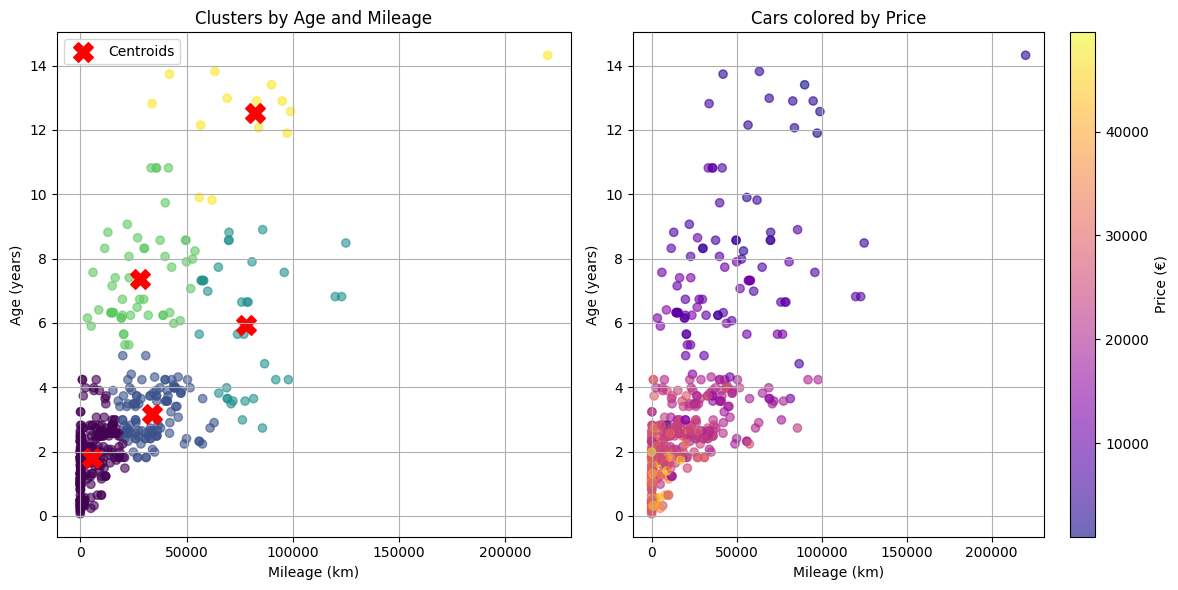

In [8]:
# Create clusters using our preprocessing utility
cleaned_dataset_with_clusters, cluster_centers, clustering_pipeline = create_car_clusters(
    cleaned_raw_dataset, 
    k=ANALYSIS_CONFIG['clustering_k'], 
    random_state=ANALYSIS_CONFIG['random_state']
)

# Analyze clusters
print("Cluster Analysis Summary:")
print("=" * 50)
cluster_summary = cleaned_dataset_with_clusters.groupby('cluster').agg({
    'mileage': ['mean', 'std', 'count'],
    'age_in_days': lambda x: (x / 365.25).mean(),  # Convert to years
    'price': ['mean', 'std', 'min', 'max']
}).round(2)

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary.rename(columns={'age_in_days_<lambda>': 'age_years_mean'}, inplace=True)
print(cluster_summary)

# Visualize clustering results
clustering_features = cleaned_raw_dataset[['mileage', 'age_in_days']].copy()
clustering_features['age_in_years'] = clustering_features['age_in_days'] / 365.25

plot_clustering_results(
    clustering_features[['mileage', 'age_in_years']], 
    cleaned_dataset_with_clusters['cluster'], 
    cluster_centers, 
    cleaned_dataset_with_clusters['price']
)

## 4. Simplified Models for Interpretability

After the complex analysis, we create simplified models that are easier to interpret and apply in practice.

### 4.1 Simple Linear Model

A basic linear model using only mileage and age as features:
```
price = base_price - a × mileage_in_1000km - b × age_in_years
```

This provides a straightforward formula for quick price estimation.

In [9]:
# Prepare training dataset
training_set = prepare_training_data(
    cleaned_dataset_with_clusters,
    max_price=ANALYSIS_CONFIG['max_price'],
    min_price=ANALYSIS_CONFIG['min_price']
)

# Prepare features and targets
X_simple_features = training_set[['mileage', 'age_in_days']].copy()
y_price = training_set['price'].copy()

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_simple_features, y_price, 
    train_size=ANALYSIS_CONFIG['train_size'],
    random_state=ANALYSIS_CONFIG['random_state'],
    stratify=training_set['cluster']
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 216 samples
Test set size: 145 samples


In [10]:
# Create and train simple linear model
simple_pipeline = create_simple_linear_model()
simple_pipeline.fit(X_train, y_train)
test_pred = simple_pipeline.predict(X_test)

# Evaluate model performance
print("Simple Linear Model Performance:")
print(f"R² score: {r2_score(y_test, test_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, test_pred):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, test_pred):.4f}")

# Extract and display model formula
formula_info = get_linear_model_formula(simple_pipeline)
print(f"\nModel formula: {formula_info['formula']}")
print(f"Price reduction: {formula_info['mileage_coefficient']:.0f}€ per 1000km, {formula_info['age_coefficient']:.0f}€ per year")

Simple Linear Model Performance:
R² score: 0.7195
MAE: 2921.65
MAPE: 0.1781

Model formula: price = 30252 - 56 * mileage_kkms - 1986 * years
Price reduction: 56€ per 1000km, 1986€ per year


### 4.2 Simple Logarithmic Model

A logarithmic model that captures exponential depreciation patterns:
```
price = base_price × exp(-a × mileage_in_1000km) × exp(-b × age_in_years) - 1
```

This model reflects the reality that cars lose value at a decreasing rate over time, showing percentage-based depreciation rather than linear.

In [11]:
# Create and train log-transformed model
simple_log_pipeline = create_log_transformed_model()
simple_log_pipeline.fit(X_train, y_train)
test_pred = simple_log_pipeline.predict(X_test)

# Evaluate model performance
print("Log-Transformed Model Performance:")
print(f"R² score: {r2_score(y_test, test_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, test_pred):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, test_pred):.4f}")

# Extract and display model formula
formula_info = get_log_model_formula(simple_log_pipeline)
print(f"\nModel formula: {formula_info['formula']}")
print(f"Price depreciation: {formula_info['mileage_depreciation_pct']:.1f}% per 1000km, {formula_info['age_depreciation_pct']:.1f}% per year")

# Validate formula accuracy
X_test_sample = X_test.head(100)  # Use smaller sample for validation
function_pred = (formula_info['base_price'] * 
                np.exp(-formula_info['mileage_coefficient'] * (X_test_sample['mileage'] / 1000)) * 
                np.exp(-formula_info['age_coefficient'] * (X_test_sample['age_in_days'] / 365.25)) - 1)
model_pred = simple_log_pipeline.predict(X_test_sample)
max_error = np.max(np.abs(function_pred - model_pred))
print(f"Formula validation - max error: {max_error:.2f}")

Log-Transformed Model Performance:
R² score: 0.7031
MAE: 2906.46
MAPE: 0.1599

Model formula: price = 34810 * exp(-0.00207 * mileage_kkms) * exp(-0.14176 * years) - 1
Price depreciation: -0.2% per 1000km, -13.2% per year
Formula validation - max error: 8.50


### 4.3 Ensemble Model (Voting Regressor)

Combine the linear and logarithmic models using a weighted voting approach. We use grid search to find the optimal weights that minimize MAPE across both models.

In [12]:
# Create ensemble model using grid search
best_model = create_ensemble_model(simple_pipeline, simple_log_pipeline, X_train, y_train)

print("Best ensemble parameters:", best_model.get_params()['weights'])

# Evaluate ensemble performance
test_pred = best_model.predict(X_test)
print("\nEnsemble Model Performance:")
print(f"R² score: {r2_score(y_test, test_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, test_pred):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, test_pred):.4f}")

# Show sample predictions
sample_cars = pd.DataFrame({
    'mileage': [0, 1000, 0],
    'age_in_days': [0, 0, 365]
})
sample_prices = best_model.predict(sample_cars)
print(f"\nSample predictions: {sample_prices}")

# Display model composition
linear_weight, log_weight = best_model.weights
print(f"Ensemble composition: {linear_weight:.2f} linear + {log_weight:.2f} log")

Fitting 5 folds for each of 11 candidates, totalling 55 fits
Best ensemble parameters: [np.float64(0.2), np.float64(0.8)]

Ensemble Model Performance:
R² score: 0.7145
MAE: 2858.53
MAPE: 0.1611

Sample predictions: [33897.43388361 33828.78085138 29819.73133761]
Ensemble composition: 0.20 linear + 0.80 log


### 4.4 Reference XGBoost model

In [13]:
# Create and train XGBoost model
xgb_model = create_xgboost_model()
xgb_model.fit(X_train, y_train)

# Evaluate XGBoost performance
test_pred = xgb_model.predict(X_test)
print("XGBoost Model Performance:")
print(f"R² score: {r2_score(y_test, test_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, test_pred):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, test_pred):.4f}")

# Sample predictions
sample_cars = pd.DataFrame({
    'mileage': [0, 1000, 0],
    'age_in_days': [0, 0, 365]
})
sample_prices = xgb_model.predict(sample_cars)
print(f"Sample predictions: {sample_prices}")

XGBoost Model Performance:
R² score: 0.6905
MAE: 3048.86
MAPE: 0.1574
Sample predictions: [24262.682 25092.004 26654.05 ]


## 5. Model Performance Visualization

Compare the performance of all three simplified models:
- Simple linear model
- Simple logarithmic model  
- Best ensemble model

The scatter plot shows predicted vs actual prices to visualize model accuracy.

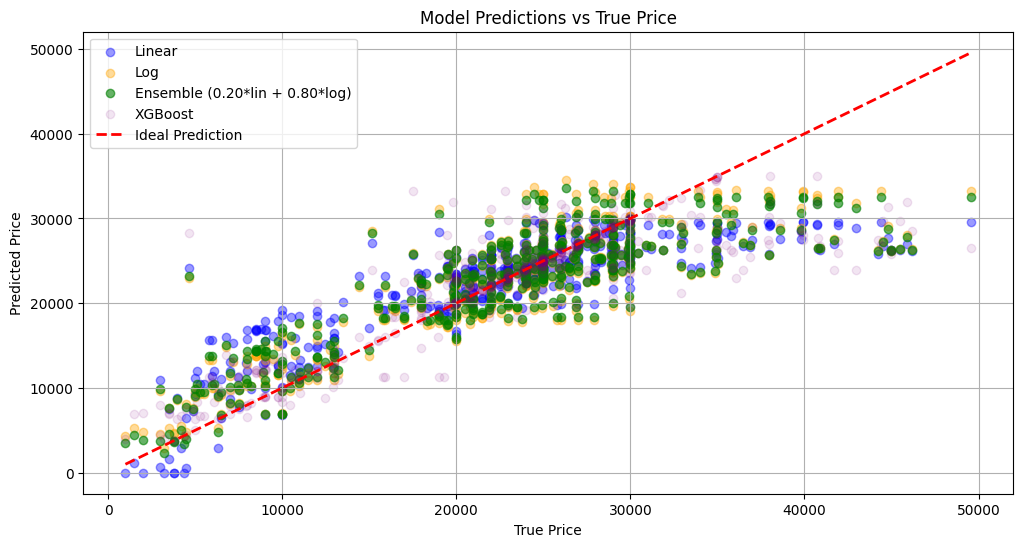

In [14]:
# Generate predictions for all models on the full dataset
X_feature = cleaned_dataset_with_clusters[['mileage', 'age_in_days']]
y_price = cleaned_dataset_with_clusters['price']

predictions = {
    'Linear': simple_pipeline.predict(X_feature),
    'Log': simple_log_pipeline.predict(X_feature),
    f'Ensemble ({best_model.weights[0]:.2f}*lin + {best_model.weights[1]:.2f}*log)': best_model.predict(X_feature),
    'XGBoost': xgb_model.predict(X_feature)
}

# Plot model predictions vs actual prices
plot_model_predictions_vs_actual(y_price, predictions)

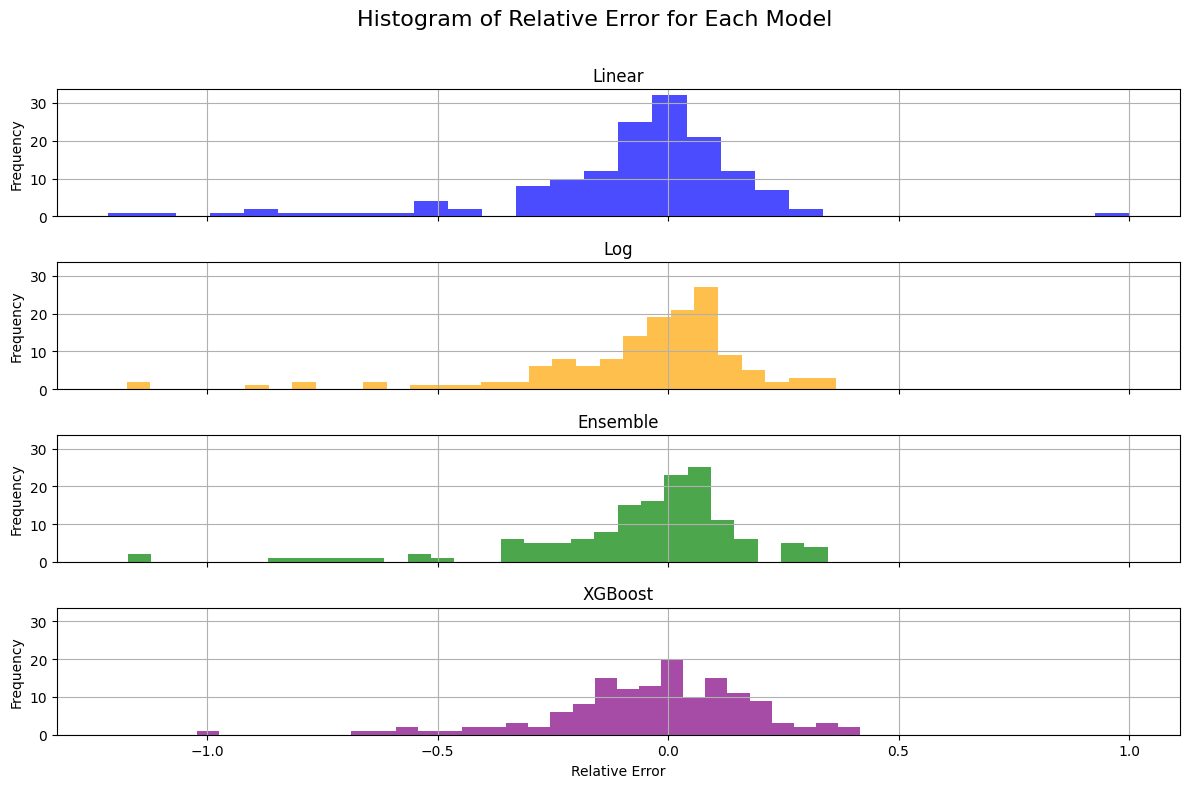

In [15]:
# Plot relative error histograms for all models
models_dict = {
    'Linear': simple_pipeline,
    'Log': simple_log_pipeline,
    'Ensemble': best_model,
    'XGBoost': xgb_model
}

plot_relative_error_histograms(X_test, y_test, models_dict)

## 6. Finding the Best Deals

Identify the most interesting cars in the dataset by comparing predicted prices with actual listing prices. Cars with the highest positive difference (predicted > actual) represent the best potential deals.

### Filtering Criteria:
- Maximum price threshold (€35,000)
- Exclude specific engine configurations (67 HP models - small battery EVs)
- Calculate relative price difference as percentage of predicted value

In [16]:
# Enrich dataset with predictions and rankings
non_archived_dataset = cleaned_dataset_with_clusters[~cleaned_dataset_with_clusters['archived']].copy()
best_model_predictions = best_model.predict(non_archived_dataset[['mileage', 'age_in_days']])
enriched_dataset = enrich_dataset_with_predictions(
    non_archived_dataset, 
    best_model, 
    best_model_predictions
)

print("MOST INTERESTING CARS (by relative price difference)")
print(f"{'='*80}")

# Apply default filters for displaying cars
filters_config = DEFAULT_FILTERS
default_filters = [
    ("Distance", "<", filters_config['max_distance']), 
    ("Price", "<", filters_config['max_price']), 
    ("Seats", ">=", filters_config['min_seats'])
]
default_order = [('Rel. Diff.', 'desc')]

show_cars(enriched_dataset, filters=default_filters, order=default_order)

MOST INTERESTING CARS (by relative price difference)


Loading ITables v2.5.2 from the internet... (need help?)


In [17]:
CARS_PER_CLUSTER = 10
print(f"\n{CARS_PER_CLUSTER} LESS EXPENSIVE CARS (by cluster)")
print("=" * 50)
for cluster_id, center in enumerate(cluster_centers):
    print(f"Cluster {cluster_id}: Mileage={center[0]:.0f} km, Age={center[1]:.1f} years")
    cluster_list = [i for i, c in enumerate(cluster_centers) if c[0] <= center[0] and c[1] <= center[1]]
    print(f"including all clusters having a center with less mileage and less age: {cluster_list}")
    cluster_cars = enriched_dataset[enriched_dataset['cluster'].isin(cluster_list)]
    if not cluster_cars.empty:
        show_cars(cluster_cars, filters=default_filters, order=[("Price", "asc")])
    else:
        print(f"Cluster {cluster_id}: No cars found.")


10 LESS EXPENSIVE CARS (by cluster)
Cluster 0: Mileage=5377 km, Age=1.8 years
including all clusters having a center with less mileage and less age: [0]


Loading ITables v2.5.2 from the internet... (need help?)


Cluster 1: Mileage=33786 km, Age=3.2 years
including all clusters having a center with less mileage and less age: [0, 1]


Loading ITables v2.5.2 from the internet... (need help?)


Cluster 2: Mileage=77916 km, Age=5.9 years
including all clusters having a center with less mileage and less age: [0, 1, 2]


Loading ITables v2.5.2 from the internet... (need help?)


Cluster 3: Mileage=28207 km, Age=7.4 years
including all clusters having a center with less mileage and less age: [0, 3]


Loading ITables v2.5.2 from the internet... (need help?)


Cluster 4: Mileage=82241 km, Age=12.5 years
including all clusters having a center with less mileage and less age: [0, 1, 2, 3, 4]


Loading ITables v2.5.2 from the internet... (need help?)


### 6.1 Specialized Vehicle Search

Filter for specific vehicle variants (XL, Grand, Long) which typically offer more space and utility, making them particularly interesting for certain use cases.

In [18]:
# Filter for specialized vehicle variants (XL, Grand, Long, Maxi)
specialized_cars = enriched_dataset[enriched_dataset['subject'].str.contains('XL|Grand|Long|Maxi', case=False, na=False)]
show_cars(specialized_cars, filters=default_filters, order=default_order)

Loading ITables v2.5.2 from the internet... (need help?)
